# PyPSA Übung 02

### Energieversorgung eines Eigenheims

Ihr Auftraggeber hat eine PV-Anlage, welche nächstes Jahr aus der EEG Förderung fällt. Er möchte nun gerne wissen, ob er die Anlage nur für den elektrischen Eigenverbrauch weiternutzen sollte (a) oder ob sich die Anschaffung eines zusätzlichen 3 kW Heizstab lohnen könnte, wodurch Teile des Wärmebedarfs gedeckt werden (b).
Welche Option (a oder b) ist ökonomisch vorteilhafter?

Elektrisches Lastprofil ist in stündlicher Auflösung im letzten Jahr durch ein Smartmeter gemessen worden und bekannt.
Einspeiseprofil der Süd-ausgerichteten PV-Anlage muss recherchiert werden. (Location ist frei wählbar, gehen Sie bspw. von Ihrem Geburtsort aus.)

Des weiteren stehen Ihnen folgende Parameter zur Verfügung: <br>
Nennleistung der PV-Anlage: 10 kWp<br>
Nennleistung des Heizstabs: 3 kW<br>
Annuität des Heizstabs: 10 €/a <br>
Kosten für Erdgas: 12,3 ct/kWh <br>
Kosten für Strom: 40,9 ct/kWh <br>
Leistung des Erdgaskessels: 10 kW <br>
Effizienz des Erdgaskessels: 0.99 <br>
Kapazität des Warmwasserspeichers: 10kWh <br>
Selbstentladungsverluste des Warmwasserspeichers: 0.5% pro Stunde


Importieren Sie zunächst die benötigten Bibliotheken

In [1]:
import pypsa
import pandas as pd
import numpy as np
%pip install "xarray<2026.4.0"
#import xarray
import gurobipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Die Lastgänge Ihres Auftraggebers sind in der Datei 'data_PyPSA_2.csv' gespeichert, lesen Sie diese mit pandas ein.

In [2]:
df_data = pd.read_csv('data_PyPSA_2.csv')
df_data

,elektrische Last,Wärmelast
0,0.433394,3.075631
1,1.030247,3.036577
2,0.542903,3.008365
3,0.584443,2.995391
4,0.524573,2.987550
...,...,...
8755,0.541104,3.538371
8756,0.851679,3.386830
8757,0.424584,3.235733
8758,0.641945,3.133662


Recherchieren Sie das Erzeugungsprofil einer PV Anlage (auf 1 kWp normiert) und lesen Sie dieses mit pandas ein.<br>
Falls die Datei in den ersten Zeilen Meta Daten entählt, können Sie beim Einlesen skiprows verwenden.

In [3]:
df_pv_data = pd.read_csv('data_PyPSA_2_pv_south.csv', skiprows=3)
df_data['PV Erzeugung'] = df_pv_data['electricity']
df_data

,elektrische Last,Wärmelast,PV Erzeugung
0,0.433394,3.075631,0.0
1,1.030247,3.036577,0.0
2,0.542903,3.008365,0.0
3,0.584443,2.995391,0.0
4,0.524573,2.987550,0.0
...,...,...,...
8755,0.541104,3.538371,0.0
8756,0.851679,3.386830,0.0
8757,0.424584,3.235733,0.0
8758,0.641945,3.133662,0.0


Definieren Sie dann alle Parameter, die Sie benötigen um das System zu implementieren.

In [4]:
#Basissystem 
pv_p_nom = 10 #in kWp
pv_p_pu = df_data['PV Erzeugung']

gas_price = 0.123 #in €/kWh
electricity_price = 0.409 # in €/kWh
electricty_import_p_nom = 20 # Leistung des Netzanschlusses in kW
boiler_eff = 0.99 #Effizienz des Gasboilers in pu
boiler_p_nom = 10 # Thermische Leistung des boilers in kW

thermal_storage_capacity = 10 # Kapazität des Speichers in kWh
thermal_storage_self_discharge = 0.005 # Selbstentladungsverluste in pu pro Stunde

#Erweiterung
heating_rod_capital_cost = 10 # Annuität, In Euro für 3 kW Heizstab
heating_rod_eff = 0.99 # Effizienz des Heizstabes
heating_rod_p_nom = 3 #Leistung des Heizstabes in kW

Erstellen Sie ein Netzwerk, dass die Problemstellung abbildet. (zunächst ohne Heizstab) <br>
Hinweis: Wenn Sie darauf achten, dass Ihre Einheiten über alle Komponenten einheitlich sind, müssen Sie nicht in MW und € rechnen, sondern können auch ct oder kW nutzen.  

In [5]:
#Network
network = pypsa.Network()
network.set_snapshots(range(8760))

# Bus
network.add("Bus", "electrical")
network.add("Bus", "thermal")

#Loads
network.add("Load", "electrical_load", bus="electrical", p_set=df_data['elektrische Last'])
network.add("Load", "thermal_load", bus="thermal", p_set=df_data['Wärmelast'])

#Generators
network.add('Generator', 'netzanschluss', bus='electrical', p_nom=electricty_import_p_nom, marginal_cost=electricity_price)
network.add("Generator", "pv", bus="electrical", p_nom=pv_p_nom, p_max_pu=pv_p_pu)
network.add("Generator", "gas_boiler", bus="thermal", p_nom=boiler_p_nom, marginal_cost=gas_price, efficiency=boiler_eff)

#Stores
network.add("Store", "thermal_storage", bus="thermal", e_nom=thermal_storage_capacity, standing_loss=thermal_storage_self_discharge)

#print("PyPSA:", pypsa.__version__)
#print("xarray:", xarray.__version__)
#print("Gurobi:", gurobipy.gurobi.version())

network.optimize(solver_name='gurobi')



C:\Users\PC\AppData\Local\Temp\ipykernel_14520\3952564981.py:25: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['electrical', 'thermal'], dtype='str', name='name')
Index(['thermal_storage'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 219.63it/s]
INFO:linopy.io: Writing time: 0.23s


Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23


Read LP format model from file C:\Users\PC\AppData\Local\Temp\linopy-problem-8x4hgddv.lp


INFO:gurobipy:Read LP format model from file C:\Users\PC\AppData\Local\Temp\linopy-problem-8x4hgddv.lp


...

INFO:gurobipy:CPU model: AMD Ryzen 5 PRO 4650U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]


Thread count: 6 physical cores, 12 logical processors, using up to 12 threads


INFO:gurobipy:Thread count: 6 physical cores, 12 logical processors, using up to 12 threads


INFO:gurobipy:


GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

'Optimieren Sie das Energiemodell mit der Methode .optimize(solver_name = 'gurobi') <br> Geben Sie sich anschließend die Ergbnisse mit den folgenden Befehlen aus:
* network.loads_t.p.plot()
* network.generators_t.p.plot()


<Axes: xlabel='snapshot'>

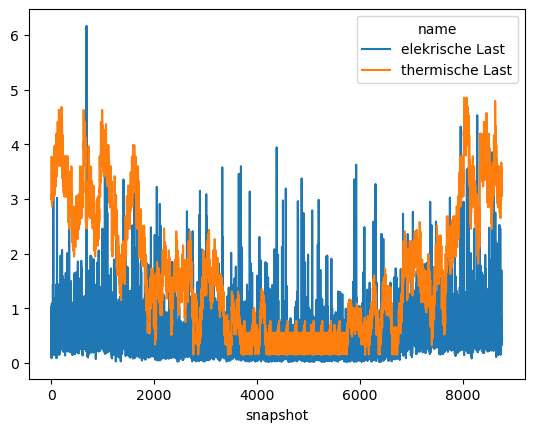

<Axes: xlabel='snapshot'>

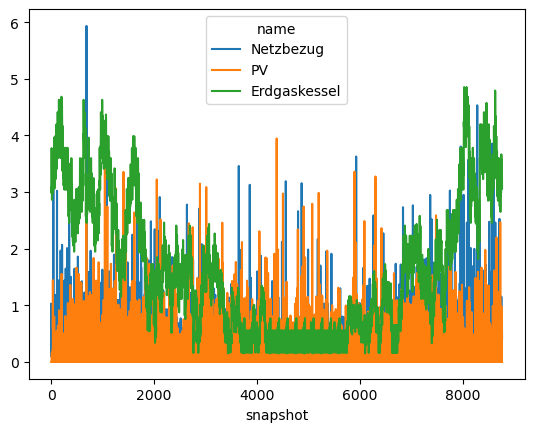

Berechnen Sie die Kosten des Systems.

2845.587342932692


Erweitern Sie das System um den Heizstab und führen Sie die Schritte ab der Optimierung erneut durch.

/tmp/ipykernel_37/4088711822.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['electrical', 'thermal'], dtype='str', name='name')
Index(['Heizstab'], dtype='str', name='name')
Index(['Warmwasserspeicher'], dtype='str', name='name')
Index(['0', '1'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 172.00it/s]
INFO:linopy.io: Writing time: 0.33s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 10129 iterations and 2.49 seconds (0.15 work units)


INFO:gurobipy:Solved in 10129 iterations and 2.49 seconds (0.15 work units)


Optimal objective  2.283622427e+03


INFO:gurobipy:Optimal objective  2.283622427e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52560 primals, 113880 duals
Objective: 2.28e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

2293.62242749138


Kosten Basissystem: 2845.59 €
Kosten Erweiterung: 2293.62 €


<Axes: xlabel='snapshot'>

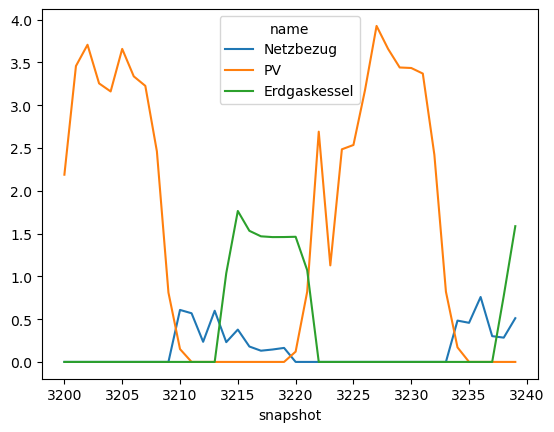